In [1]:
# Cell 1: Imports and parameters
import os
os.environ['JAX_PLATFORMS'] = 'cpu'  # Force JAX to use CPU

import jax
import jax.numpy as jnp
from jax.experimental.ode import odeint
import numpy as np

# Verify we're using CPU
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")


JAX backend: cpu
Available devices: [CpuDevice(id=0)]


In [2]:

# System size and mass
N = 5   # number of masses
mass = 1.0

# Unpack parameters: p[0]=k (spring stiffness), p[1:] = beta (Duffing coeffs)
def unpack_params(p):
    k = p[0]
    beta = p[1:]
    return k, beta

In [3]:
# Cell 2: Forcing and system dynamics
def forcing(t):
    # sinusoidal drive on mass index 0
    return jnp.array([jnp.sin(2.0 * t)] + [0.0] * (N - 1))

def dynamics(state, t, p):
    # state = [x_0, ..., x_{N-1}, v_0, ..., v_{N-1}]
    x, v = jnp.split(state, 2)
    k, beta = unpack_params(p)

    # fixed‐end springs → pad x with zeros at both ends
    x_pad = jnp.concatenate([jnp.array([0.0]), x, jnp.array([0.0])])
    # linear spring forces
    Kx = k * (2 * x - x_pad[:-2] - x_pad[2:])
    # local Duffing nonlinearity
    duff = -beta * x**3
    # acceleration
    a = ( -Kx + duff + forcing(t) ) / mass

    return jnp.concatenate([v, a])

In [4]:
# Cell 3: Create a synthetic “true” trajectory
p_true = jnp.array([3.0] + [0.5] * N)   # true parameters
t_final = 10.0
num_steps = 200
ts = jnp.linspace(0.0, t_final, num_steps)
init_state = jnp.zeros(2 * N)

# forward integrate to get target
target_states = odeint(dynamics, init_state, ts, p_true)
target_traj  = target_states[:, N-1]    # record last mass’s position
print("Target trajectory shape:", target_traj.shape)

Target trajectory shape: (200,)


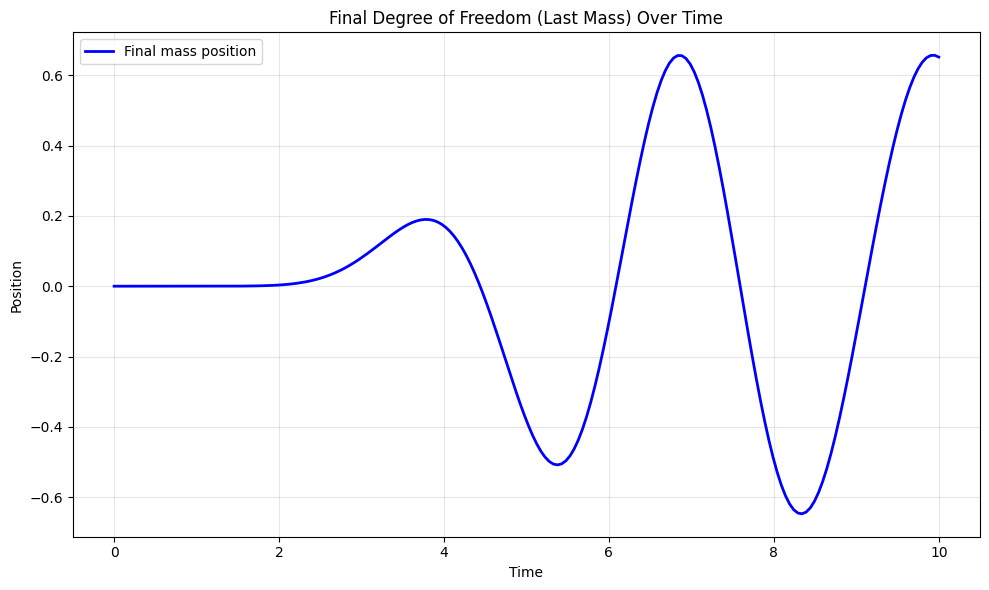

Final mass trajectory range: [-0.6471, 0.6567]


In [5]:
# Cell 5: Plot the final DOF over time
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ts, target_traj, 'b-', linewidth=2, label='Final mass position')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Final Degree of Freedom (Last Mass) Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final mass trajectory range: [{target_traj.min():.4f}, {target_traj.max():.4f}]")


In [6]:
# Cell 4: Define and evaluate the loss
def loss_fn(p):
    states = odeint(dynamics, init_state, ts, p)
    x_end  = states[:, N-1]
    return 0.5 * jnp.trapezoid((x_end - target_traj)**2, ts)

p_test = p_true * 1.1
print("Loss at p_test:", loss_fn(p_test))

Loss at p_test: 0.076142624


In [7]:
# Cell 7: Compute the adjoint‐based gradient

# (a) replay forward trajectory at p_test
states = odeint(dynamics, init_state, ts, p_test)

# (b) interpolation helper for target_traj
def target_interp(t):
    return jnp.interp(t, ts, target_traj)

# (c) interpolation helper for state trajectory
def state_interp(t, states_traj):
    # Interpolate each component of the state vector
    state_components = []
    for i in range(states_traj.shape[1]):
        component = jnp.interp(t, ts, states_traj[:, i])
        state_components.append(component)
    return jnp.array(state_components)

# (d) running‐cost gradient: ∇_u g = (x_end - target) on DOF N-1
def running_cost_grad(state, t):
    x, v = jnp.split(state, 2)
    gx = jnp.zeros_like(x).at[N-1].set(x[N-1] - target_interp(t))
    gv = jnp.zeros_like(v)
    return jnp.concatenate([gx, gv])  # gradient wrt [x, v] = [∇_x g, 0]

# (e) Jacobian of dynamics wrt state
jac_dyn = jax.jacfwd(dynamics, argnums=0)

# (f) adjoint ODE: da/dt = -J^T a - ∇g
def adjoint_ode(a, t, p, states_traj):
    u = state_interp(t, states_traj)
    J = jac_dyn(u, t, p)
    return -(J.T @ a) - running_cost_grad(u, t)

# integrate adjoint backward in time
# For backward integration, we need to reverse time: τ = T - t
T = t_final
def adjoint_ode_reversed(a, tau, p, states_traj):
    t = T - tau  # convert back to forward time
    return -adjoint_ode(a, t, p, states_traj)  # negative because we're going backward

tau_span = jnp.linspace(0.0, T, num_steps)  # τ goes from 0 to T
aT = jnp.zeros(2 * N)  # terminal condition a(T) = 0

# Integrate backward
a_rev = odeint(lambda a, tau: adjoint_ode_reversed(a, tau, p_test, states), 
               aT, tau_span)

# Convert back to forward time order
a_traj = a_rev[::-1]

print("Adjoint trajectory shape:", a_traj.shape)
print("Forward states shape:", states.shape)

Adjoint trajectory shape: (200, 10)
Forward states shape: (200, 10)


In [8]:
# Cell 8: Form the gradient integral and compare to autodiff

# (f) Jacobian of dynamics wrt parameters
jac_params = jax.jacfwd(dynamics, argnums=2)

# build overlap integrand a^T ∂_p f for the adjoint gradient formula
ints = []
for a, u, t in zip(a_traj, states, ts):
    Jp = jac_params(u, t, p_test)            # shape (2N, num_params)
    ints.append((a[:, None].T @ Jp)[0])      # (1, num_params) -> (num_params,)
ints = jnp.stack(ints)                       # (num_steps, num_params)

# gradient from adjoint formula: ∇_p J = ∫ a^T ∂f/∂p dt
grad_adjoint = jnp.trapezoid(ints, ts, axis=0)
print("Adjoint gradient:", grad_adjoint)

# autodiff for verification
grad_auto = jax.grad(loss_fn)(p_test)
print("Autodiff gradient:", grad_auto)

print("\nDifference:", grad_adjoint - grad_auto)
print("Relative error:", jnp.abs(grad_adjoint - grad_auto) / (jnp.abs(grad_auto) + 1e-8))

Adjoint gradient: [0.42958516 0.00668439 0.0060671  0.00115524 0.00770379 0.02032965]
Autodiff gradient: [0.42997387 0.00669034 0.00607599 0.00115673 0.00771226 0.02035073]

Difference: [-3.8871169e-04 -5.9488229e-06 -8.8908710e-06 -1.4916295e-06
 -8.4689818e-06 -2.1083280e-05]
Relative error: [0.00090404 0.00088916 0.00146328 0.00128951 0.00109812 0.001036  ]


In [15]:

# Cell 9: ε-rule implementation (corrected)
ε = 1e-6  # small amplitude

# For pure running cost problems (no terminal cost):
# w(0) = u(0) (same initial condition - no terminal cost perturbation)
w0 = init_state

# Define modified dynamics: dw/dt = f(w,t,p) + ε·∇g(w,t) 
def w_dynamics(w, t, p):
    base = dynamics(w, t, p)
    rung = running_cost_grad(w, t)   # ∇g at each time
    return base + ε * rung

# Integrate the perturbed system forward
w_states = odeint(w_dynamics, w0, ts, p_test)

# Extract the difference v = w - u
v_states = w_states - states

# Gradient via ε-rule: ∇_p J = (1/ε) * ∫ v^T * ∂f/∂p dt
ints = []
for v, u, t in zip(v_states, states, ts):
    Jp = jax.jacfwd(dynamics, argnums=2)(u, t, p_test)  # ∂f/∂p
    ints.append((v[:, None].T @ Jp)[0])
ints = jnp.stack(ints)

grad_eps = (1/ε) * jnp.trapezoid(ints, ts, axis=0)  # Note: positive sign

print("ε-rule gradient:", grad_eps)
print("Adjoint gradient:", grad_adjoint)
print("Autodiff gradient:", grad_auto)

print("\nε-rule vs Adjoint difference:", grad_eps - grad_adjoint)
print("ε-rule vs Autodiff difference:", grad_eps - grad_auto)

ε-rule gradient: [0. 0. 0. 0. 0. 0.]
Adjoint gradient: [0.42958516 0.00668439 0.0060671  0.00115524 0.00770379 0.02032965]
Autodiff gradient: [0.42997387 0.00669034 0.00607599 0.00115673 0.00771226 0.02035073]

ε-rule vs Adjoint difference: [-0.42958516 -0.00668439 -0.0060671  -0.00115524 -0.00770379 -0.02032965]
ε-rule vs Autodiff difference: [-0.42997387 -0.00669034 -0.00607599 -0.00115673 -0.00771226 -0.02035073]
